In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('ad_10000records.csv')
data

,DailyTimeSpentOnSite,Age,AreaIncome,DailyInternetUsage,AdTopicLine,City,Gender,Country,Timestamp,ClickedOnAd
0,62.26,32.0,69481.85,172.83,Decentralized real-time circuit,Lisafort,Male,Svalbard & Jan Mayen Islands,2016-06-09 21:43:05,0
1,41.73,31.0,61840.26,207.17,Optional full-range projection,West Angelabury,Male,Singapore,2016-01-16 17:56:05,0
2,44.40,30.0,57877.15,172.83,Total 5thgeneration standardization,Reyesfurt,Female,Guadeloupe,2016-06-29 10:50:45,0
3,59.88,28.0,56180.93,207.17,Balanced empowering success,New Michael,Female,Zambia,2016-06-21 14:32:32,0
4,49.21,30.0,54324.73,201.58,Total 5thgeneration standardization,West Richard,Female,Qatar,2016-07-21 10:54:35,1
...,...,...,...,...,...,...,...,...,...,...
9995,41.73,31.0,61840.26,207.17,Profound executive flexibility,West Angelabury,Male,Singapore,2016-01-03 03:22:15,1
9996,41.73,28.0,51501.38,120.49,Managed zero tolerance concept,Kennedyfurt,Male,Luxembourg,2016-05-28 12:20:15,0
9997,55.60,39.0,38067.08,124.44,Intuitive exuding service-desk,North Randy,Female,Egypt,2016-01-05 11:53:17,0
9998,46.61,50.0,43974.49,123.13,Realigned content-based leverage,North Samantha,Female,Malawi,2016-04-04 07:07:46,1


In [3]:
data.shape

(10000, 10)

In [4]:
data.info

<bound method DataFrame.info of       DailyTimeSpentOnSite   Age  AreaIncome  DailyInternetUsage  \
0                    62.26  32.0    69481.85              172.83   
1                    41.73  31.0    61840.26              207.17   
2                    44.40  30.0    57877.15              172.83   
3                    59.88  28.0    56180.93              207.17   
4                    49.21  30.0    54324.73              201.58   
...                    ...   ...         ...                 ...   
9995                 41.73  31.0    61840.26              207.17   
9996                 41.73  28.0    51501.38              120.49   
9997                 55.60  39.0    38067.08              124.44   
9998                 46.61  50.0    43974.49              123.13   
9999                 46.61  43.0    60575.99              198.45   

                                 AdTopicLine             City  Gender  \
0            Decentralized real-time circuit         Lisafort    Male   
1    

Check if there is any null value or not.

In [5]:
data.isnull().sum()

DailyTimeSpentOnSite    0
Age                     0
AreaIncome              0
DailyInternetUsage      0
AdTopicLine             0
City                    0
Gender                  0
Country                 0
Timestamp               0
ClickedOnAd             0
dtype: int64

Check if there is any duplicated data or not and remove them.

In [6]:
data.duplicated().sum()

215

In [7]:
data = data.drop_duplicates()
data.shape

(9785, 10)

Count number of different adds that be showed to people and different cities and countries.

In [8]:
plot_df = data.AdTopicLine.value_counts()
plot_df

Cloned explicit middleware                 323
Sharable reciprocal project                187
Business-focused transitional solution     186
Intuitive exuding service-desk             173
Managed client-server access               152
                                          ... 
Ergonomic neutral portal                     1
Implemented uniform synergy                  1
Visionary multi-tasking alliance             1
Inverse zero tolerance customer loyalty      1
Reactive interactive protocol                1
Name: AdTopicLine, Length: 559, dtype: int64

In [9]:
plot_df = data.City.value_counts()
plot_df

Hubbardmouth      330
Lisafort          235
Wintersfort       225
Reyesfurt         205
Stewartbury       204
                 ... 
Turnerview          1
North Tiffany       1
North Kristine      1
East Troyhaven      1
Davidview           1
Name: City, Length: 521, dtype: int64

In [10]:
plot_df = data.Country.value_counts()
plot_df

Australia                                       346
Czech Republic                                  325
Turkey                                          296
Qatar                                           222
Hong Kong                                       221
                                               ... 
South Georgia and the South Sandwich Islands      1
Wallis and Futuna                                 1
Sierra Leone                                      1
Niue                                              1
Paraguay                                          1
Name: Country, Length: 207, dtype: int64

Check the distribution of gender.

<AxesSubplot: >

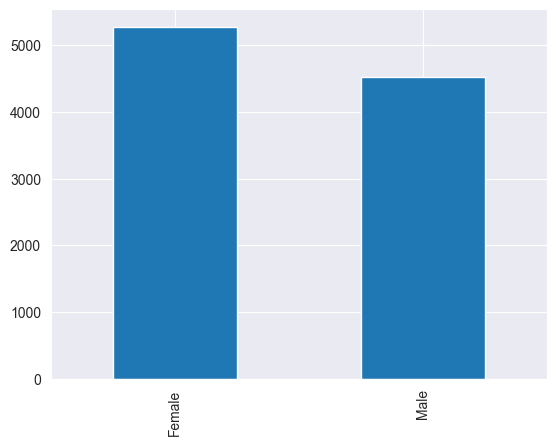

In [11]:
plot_df = data.Gender.value_counts()
plot_df.plot(kind="bar")

In this part we will cluster the ADs to some group. In this way we can work with them better than the way if we vectorized them and use them.
In that way our data would become big and make our model heavy and hard to work.

In [12]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import DBSCAN

# Assuming the text data is in the 'text' column
text_data = data['AdTopicLine'].tolist()

# Vectorize the text
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(text_data)

# Cluster the text data using DBSCAN
model = DBSCAN(eps=0.5, min_samples=2)
labels = model.fit_predict(X)

# Group the text data by cluster
groups = [[] for _ in set(labels)]
for i, label in enumerate(labels):
    groups[label].append(text_data[i])

# Add the groups as a new column to the original dataset
data['group'] = labels

data

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3864\2278208725.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['group'] = labels


,DailyTimeSpentOnSite,Age,AreaIncome,DailyInternetUsage,AdTopicLine,City,Gender,Country,Timestamp,ClickedOnAd,group
0,62.26,32.0,69481.85,172.83,Decentralized real-time circuit,Lisafort,Male,Svalbard & Jan Mayen Islands,2016-06-09 21:43:05,0,0
1,41.73,31.0,61840.26,207.17,Optional full-range projection,West Angelabury,Male,Singapore,2016-01-16 17:56:05,0,1
2,44.40,30.0,57877.15,172.83,Total 5thgeneration standardization,Reyesfurt,Female,Guadeloupe,2016-06-29 10:50:45,0,2
3,59.88,28.0,56180.93,207.17,Balanced empowering success,New Michael,Female,Zambia,2016-06-21 14:32:32,0,3
4,49.21,30.0,54324.73,201.58,Total 5thgeneration standardization,West Richard,Female,Qatar,2016-07-21 10:54:35,1,2
...,...,...,...,...,...,...,...,...,...,...,...
9994,41.73,28.0,39799.73,217.37,Realigned intangible benchmark,Dustinchester,Female,Zambia,2016-03-20 02:44:13,0,184
9995,41.73,31.0,61840.26,207.17,Profound executive flexibility,West Angelabury,Male,Singapore,2016-01-03 03:22:15,1,256
9996,41.73,28.0,51501.38,120.49,Managed zero tolerance concept,Kennedyfurt,Male,Luxembourg,2016-05-28 12:20:15,0,61
9997,55.60,39.0,38067.08,124.44,Intuitive exuding service-desk,North Randy,Female,Egypt,2016-01-05 11:53:17,0,15


In [13]:
data.group.value_counts()

47     323
52     187
43     186
15     173
118    152
      ... 
360      2
356      2
353      2
349      2
448      2
Name: group, Length: 450, dtype: int64

In [14]:
from sklearn.metrics import silhouette_score

silhouette_score(X, data['group'])

0.9853369506082652

The silhouette score is a measure of how well each data point fits into its assigned cluster. It ranges from -1 to 1, with a higher score indicating better clustering.
By using silhouette score we can see that our clustering has a good performance and our clustering is good for our data and models.

Let's check the relation of the clicking and daily time spent on site.

Text(0.5, 1.0, 'Relationship between Clicking and Daily time spent on site')

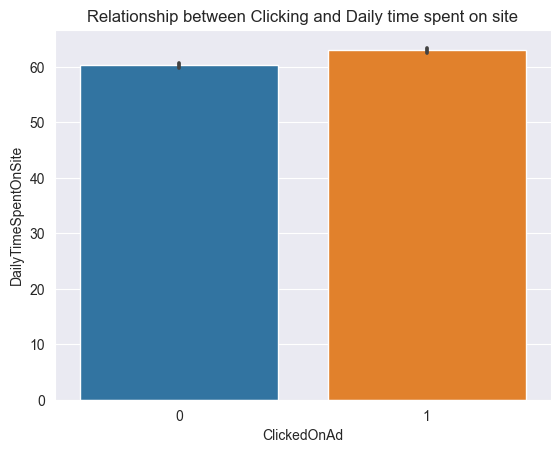

In [15]:
sns.barplot(x='ClickedOnAd', y='DailyTimeSpentOnSite', data=data)
plt.title('Relationship between Clicking and Daily time spent on site')

Text(0.5, 1.0, 'Distribution of Daily time spent on site by Clicking')

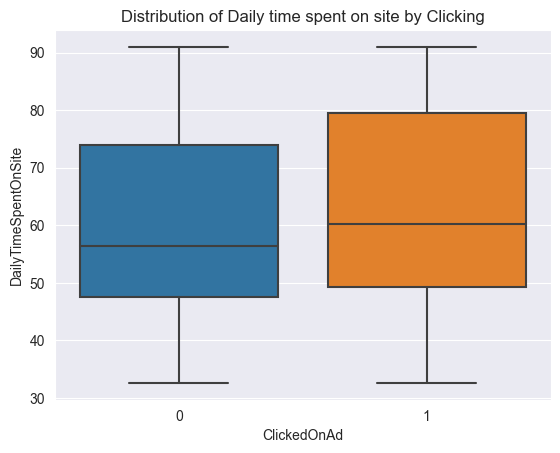

In [16]:
sns.boxplot(x='ClickedOnAd', y='DailyTimeSpentOnSite', data=data)
plt.title('Distribution of Daily time spent on site by Clicking')

Text(0.5, 1.0, 'Distribution of Daily time spent on site by Clicking')

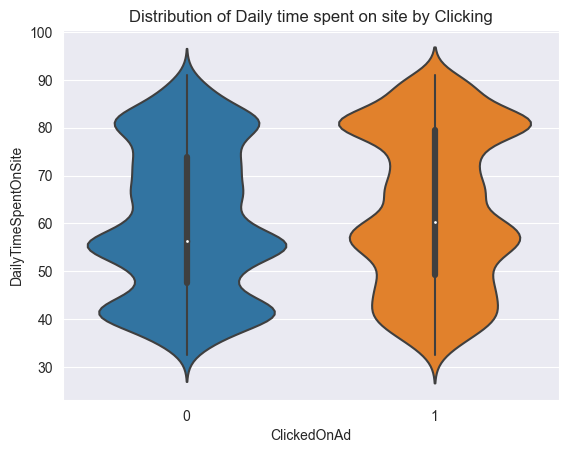

In [17]:
sns.violinplot(x='ClickedOnAd', y='DailyTimeSpentOnSite', data=data)
plt.title('Distribution of Daily time spent on site by Clicking')

Text(0.5, 0.98, 'Distribution of Daily time spent on site by Clicking')

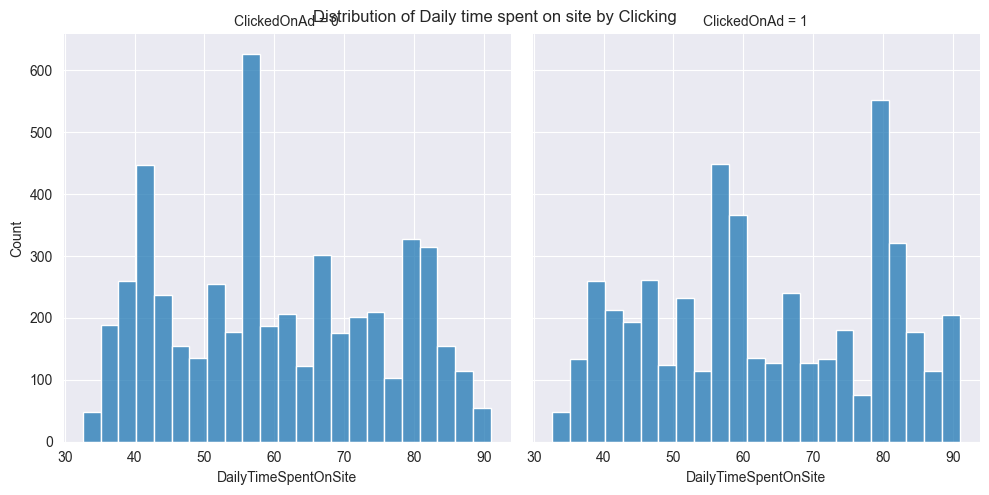

In [18]:
sns.displot(data=data, x='DailyTimeSpentOnSite', col='ClickedOnAd', kind='hist')
plt.suptitle('Distribution of Daily time spent on site by Clicking')

As we can see if you spend more time on site there is a little more chance that you click on the AD.

Now check the clicking and age

Text(0.5, 1.0, 'Relationship between Clicking and Age')

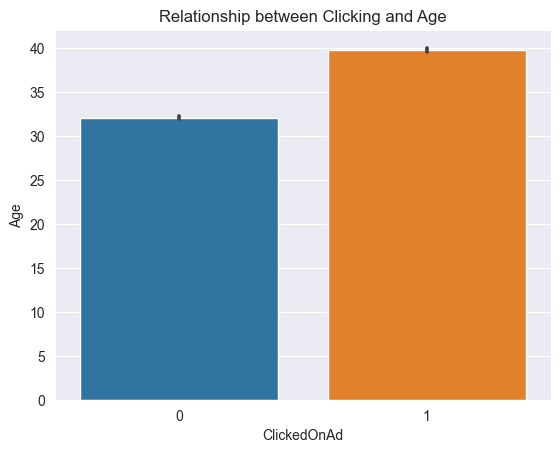

In [19]:
sns.barplot(x='ClickedOnAd', y='Age', data=data)
plt.title('Relationship between Clicking and Age')

Text(0.5, 1.0, 'Distribution of Age by Clicking')

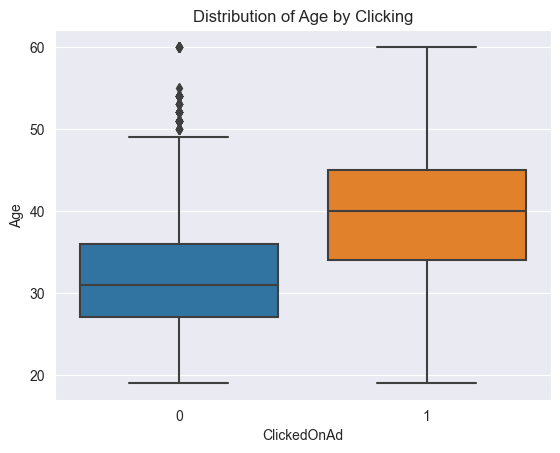

In [20]:
sns.boxplot(x='ClickedOnAd', y='Age', data=data)
plt.title('Distribution of Age by Clicking')

Text(0.5, 1.0, 'Distribution of Age by Clicking')

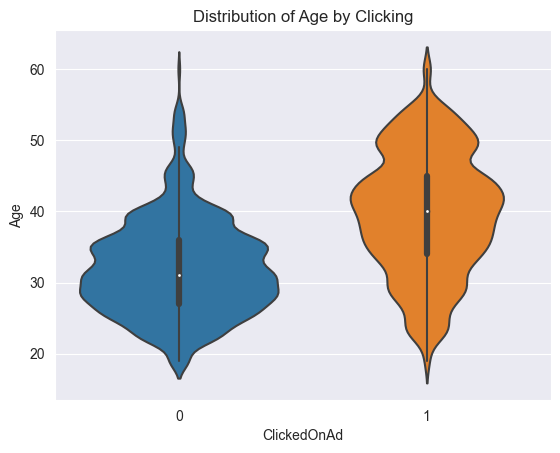

In [21]:
sns.violinplot(x='ClickedOnAd', y='Age', data=data)
plt.title('Distribution of Age by Clicking')

Text(0.5, 0.98, 'Distribution of Age by Clicking')

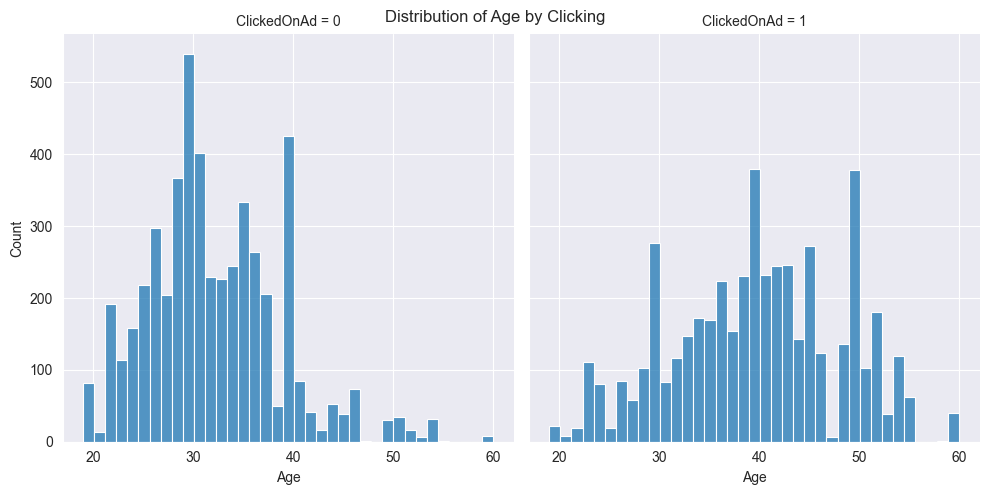

In [22]:
sns.displot(data=data, x='Age', col='ClickedOnAd', kind='hist')
plt.suptitle('Distribution of Age by Clicking')

As above, older people would click on the ADs more often and more than younger people.

Let's check the Area Income and clicking

Text(0.5, 1.0, 'Relationship between Clicking and AreaIncome')

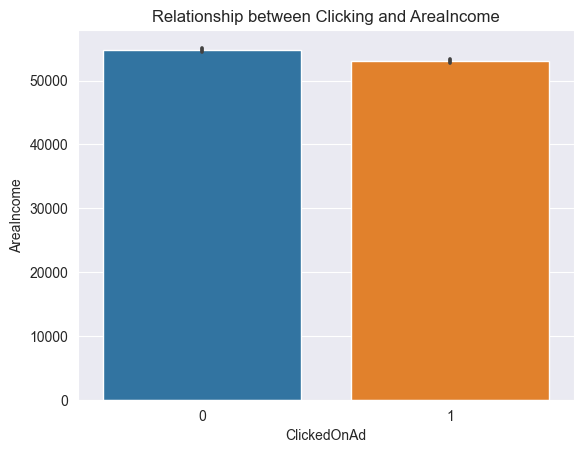

In [23]:
sns.barplot(x='ClickedOnAd', y='AreaIncome', data=data)
plt.title('Relationship between Clicking and AreaIncome')

Text(0.5, 1.0, 'Distribution of AreaIncome by Clicking')

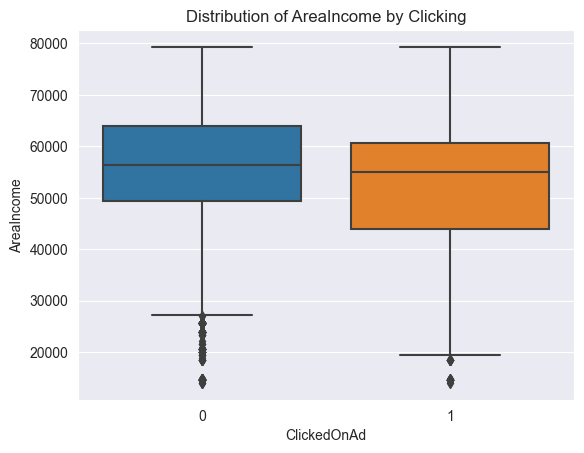

In [24]:
sns.boxplot(x='ClickedOnAd', y='AreaIncome', data=data)
plt.title('Distribution of AreaIncome by Clicking')

Text(0.5, 1.0, 'Distribution of AreaIncome by Clicking')

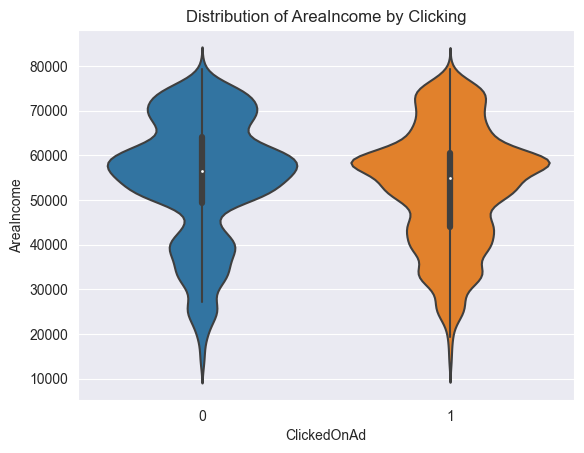

In [25]:
sns.violinplot(x='ClickedOnAd', y='AreaIncome', data=data)
plt.title('Distribution of AreaIncome by Clicking')

Text(0.5, 0.98, 'Distribution of AreaIncome by Clicking')

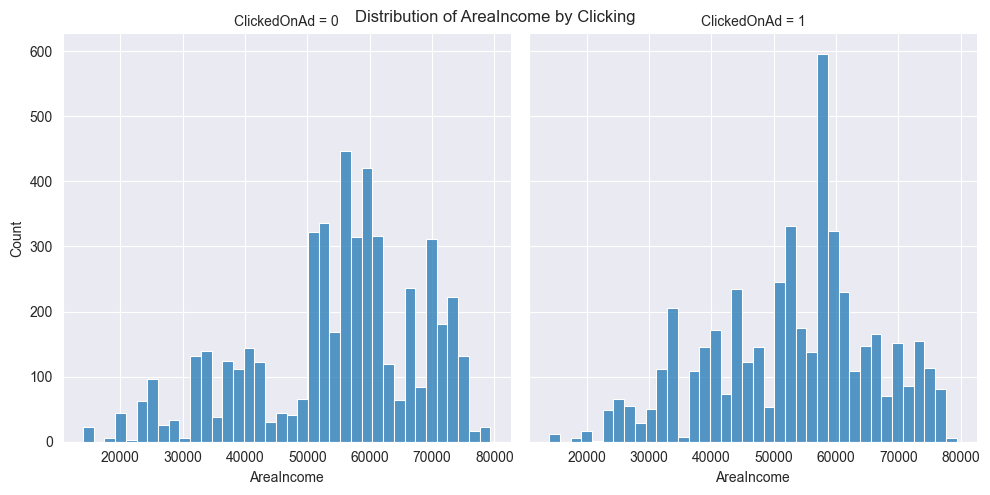

In [26]:
sns.displot(data=data, x='AreaIncome', col='ClickedOnAd', kind='hist')
plt.suptitle('Distribution of AreaIncome by Clicking')

In fact there is no any relation between these two feature by above plots.

Now the time spent in the site and the internet usage.

Text(0.5, 1.0, 'Correlation Matrix')

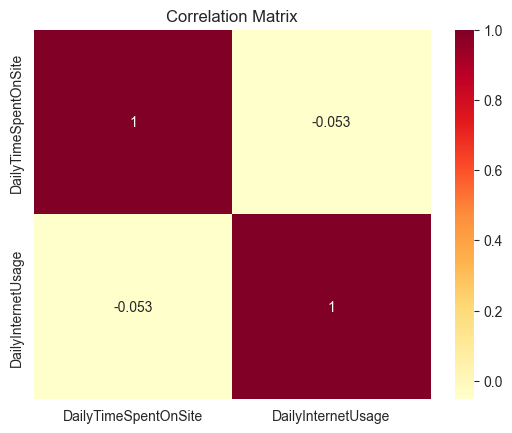

In [27]:
corr_matrix = data[['DailyTimeSpentOnSite', 'DailyInternetUsage']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='YlOrRd')
plt.title('Correlation Matrix')

Now usage of internet and clicking

Text(0.5, 1.0, 'Relationship between Clicking and Age')

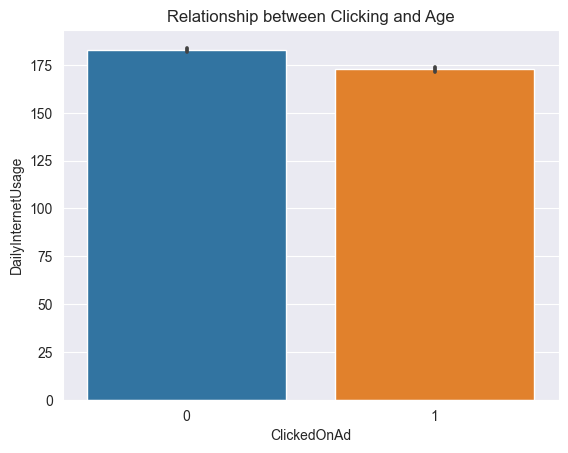

In [28]:
sns.barplot(x='ClickedOnAd', y='DailyInternetUsage', data=data)
plt.title('Relationship between Clicking and Age')

Text(0.5, 1.0, 'Distribution of AreaIncome by Clicking')

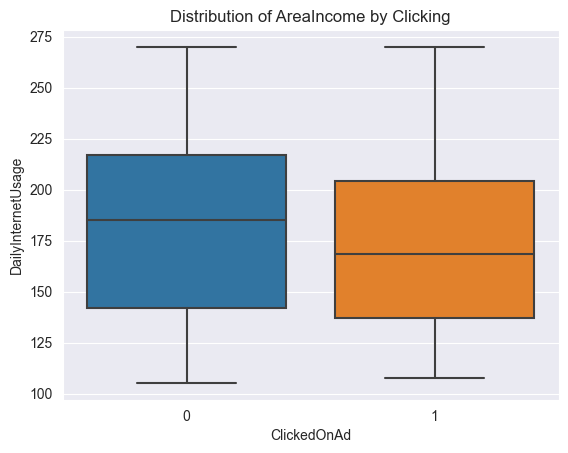

In [29]:
sns.boxplot(x='ClickedOnAd', y='DailyInternetUsage', data=data)
plt.title('Distribution of AreaIncome by Clicking')

Text(0.5, 1.0, 'Distribution of AreaIncome by Clicking')

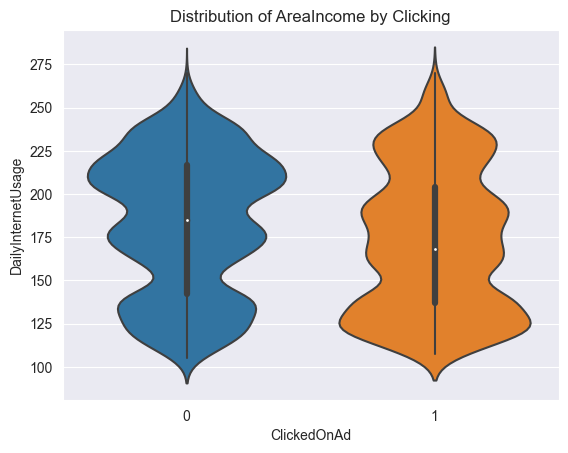

In [30]:
sns.violinplot(x='ClickedOnAd', y='DailyInternetUsage', data=data)
plt.title('Distribution of AreaIncome by Clicking')

Text(0.5, 0.98, 'Distribution of AreaIncome by Clicking')

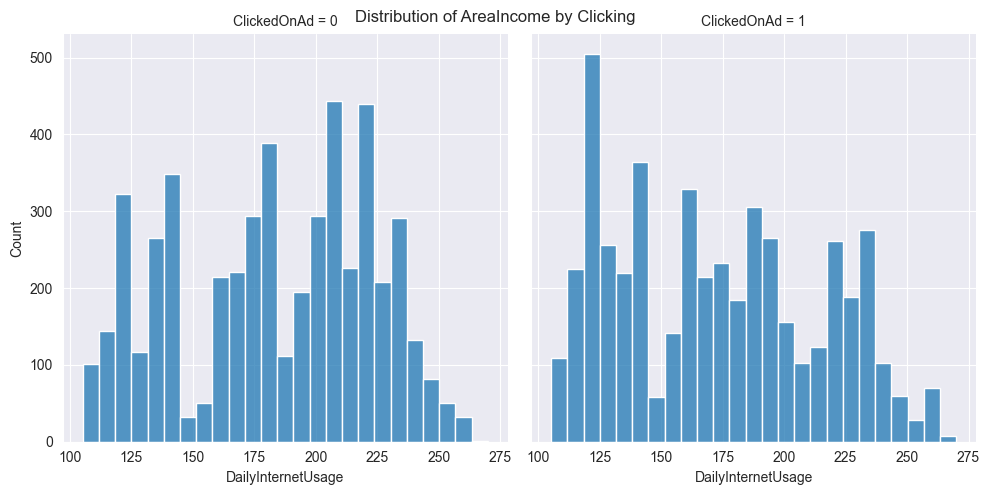

In [31]:
sns.displot(data=data, x='DailyInternetUsage', col='ClickedOnAd', kind='hist')
plt.suptitle('Distribution of AreaIncome by Clicking')

If people have a higher daily internet usage they usually less click on the ADs.

Text(0.5, 1.0, 'Correlation Matrix')

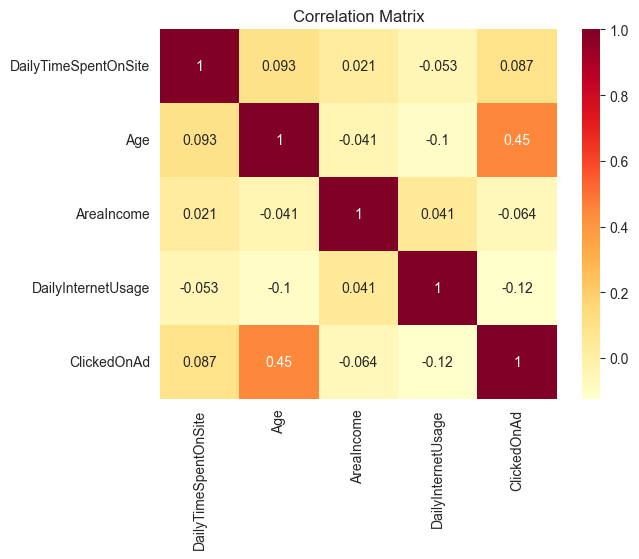

In [32]:
corr_matrix = data[['DailyTimeSpentOnSite', 'Age', 'AreaIncome', 'DailyInternetUsage', 'ClickedOnAd']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='YlOrRd')
plt.title('Correlation Matrix')

Gender and clicking

Text(0.5, 1.0, 'Relationship between gender and clicking')

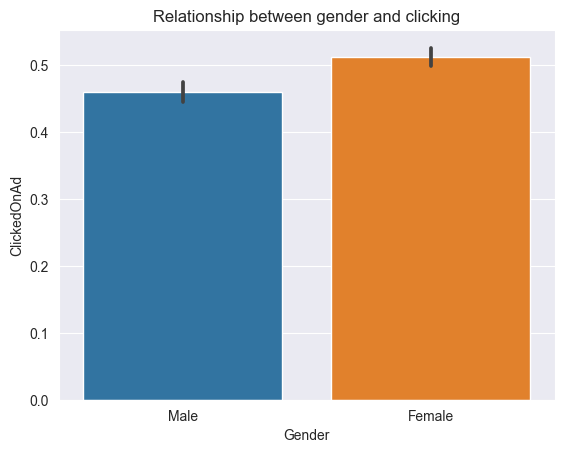

In [33]:
sns.barplot(x='Gender', y='ClickedOnAd', data=data)
plt.title('Relationship between gender and clicking')

Text(0.5, 1.0, 'Proportions of Gender by Clicking Groups')

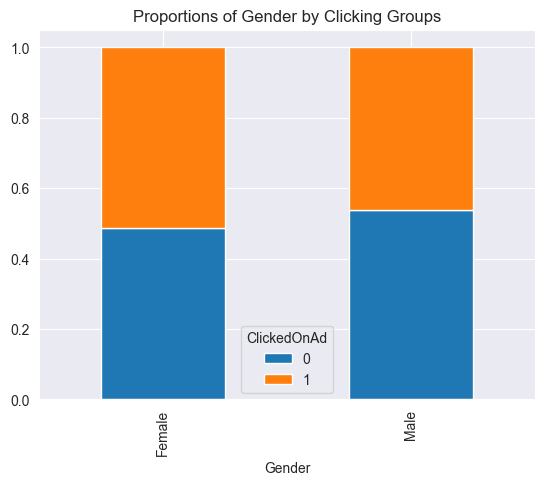

In [34]:
data.groupby('Gender')['ClickedOnAd'].value_counts(normalize=True).unstack().plot(kind='bar', stacked=True)
plt.title('Proportions of Gender by Clicking Groups')

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3864\2488142318.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  matrix['Gender'] = encoder.fit_transform(matrix[['Gender']])


Text(0.5, 1.0, 'Correlation Matrix')

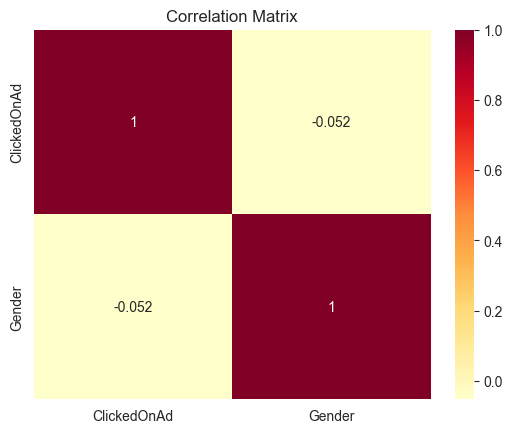

In [35]:
from sklearn.preprocessing import OrdinalEncoder

matrix = data[['ClickedOnAd', 'Gender']]
encoder = OrdinalEncoder()
matrix['Gender'] = encoder.fit_transform(matrix[['Gender']])
corr_matrix = matrix.corr()
sns.heatmap(corr_matrix, annot=True, cmap='YlOrRd')
plt.title('Correlation Matrix')

<AxesSubplot: xlabel='DailyInternetUsage', ylabel='Density'>

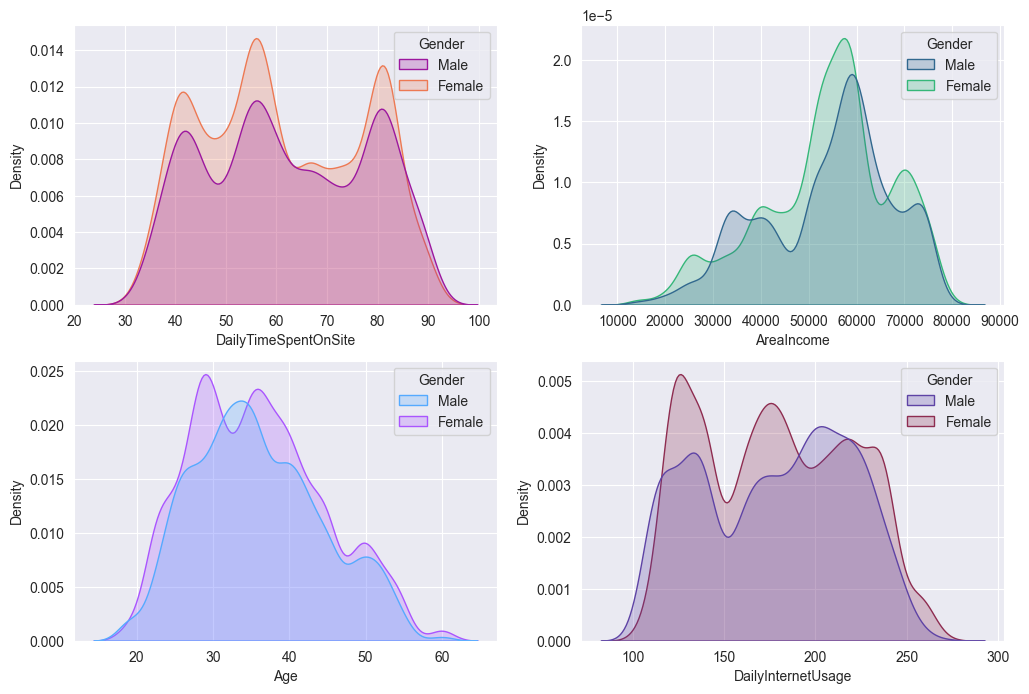

In [36]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

sns.kdeplot(data=data, hue='Gender', x='DailyTimeSpentOnSite', ax=axs[0][0], palette='plasma', fill=True)
sns.kdeplot(data=data, hue='Gender', x='Age', ax=axs[1][0], palette='cool', fill=True)
sns.kdeplot(data=data, hue='Gender', x='AreaIncome', ax=axs[0][1], palette='viridis', fill=True)
sns.kdeplot(data=data, hue='Gender', x='DailyInternetUsage', ax=axs[1][1], palette='twilight', fill=True)

<AxesSubplot: xlabel='Gender', ylabel='DailyInternetUsage'>

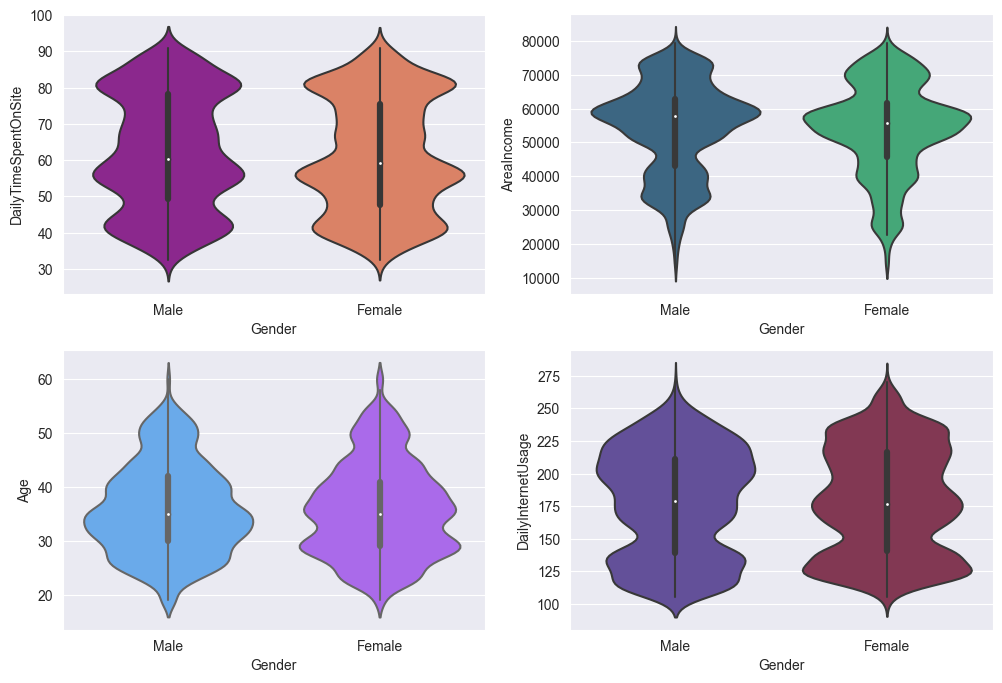

In [37]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

sns.violinplot(data=data, x='Gender', y='DailyTimeSpentOnSite', ax=axs[0][0], palette='plasma')
sns.violinplot(data=data, x='Gender', y='Age', ax=axs[1][0], palette='cool')
sns.violinplot(data=data, x='Gender', y='AreaIncome', ax=axs[0][1], palette='viridis')
sns.violinplot(data=data, x='Gender', y='DailyInternetUsage', ax=axs[1][1], palette='twilight')

By using these plots we can see that both male and female are approximately in a same amount active on social media and site but females click onn ADs more often.

<AxesSubplot: xlabel='DailyInternetUsage', ylabel='Density'>

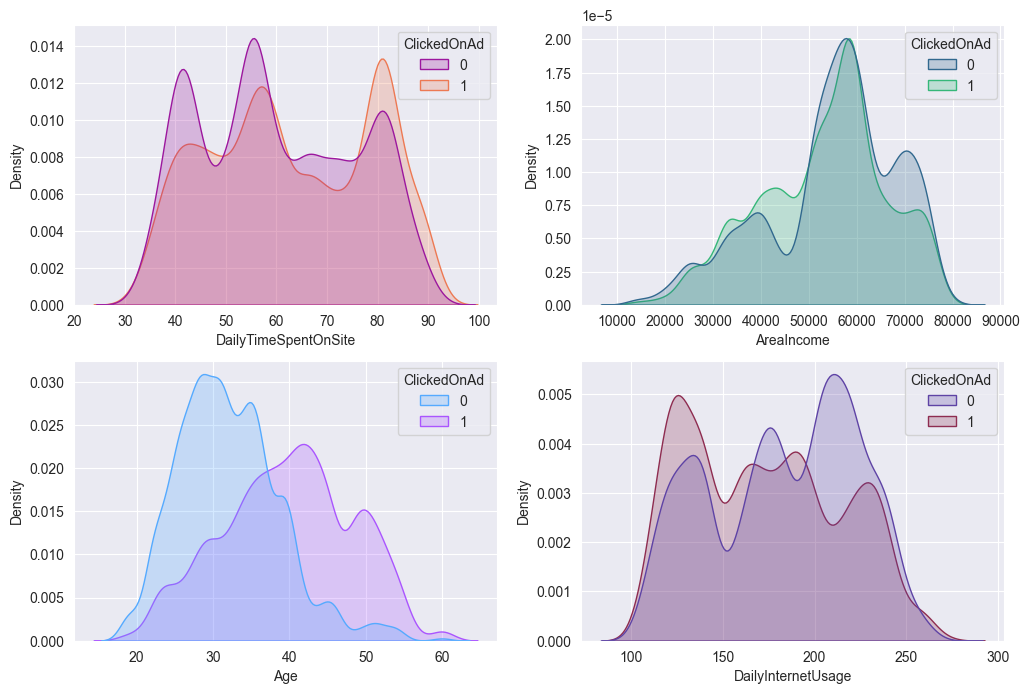

In [38]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

sns.kdeplot(data=data, hue='ClickedOnAd', x='DailyTimeSpentOnSite', ax=axs[0][0], palette='plasma', fill=True)
sns.kdeplot(data=data, hue='ClickedOnAd', x='Age', ax=axs[1][0], palette='cool', fill=True)
sns.kdeplot(data=data, hue='ClickedOnAd', x='AreaIncome', ax=axs[0][1], palette='viridis', fill=True)
sns.kdeplot(data=data, hue='ClickedOnAd', x='DailyInternetUsage', ax=axs[1][1], palette='twilight', fill=True)

From the plots, it appears that the average Age and Daily time spent on site are higher for users who have clicked on ads, compared to those who have not. This indicates that older users and those who spend more time on the site on a daily basis are more likely to engage with the ads and click on them. On the other hand, the analysis also shows that the average values for the other two features (which were not specified) are higher for users who have not clicked on ads, compared to those who have.

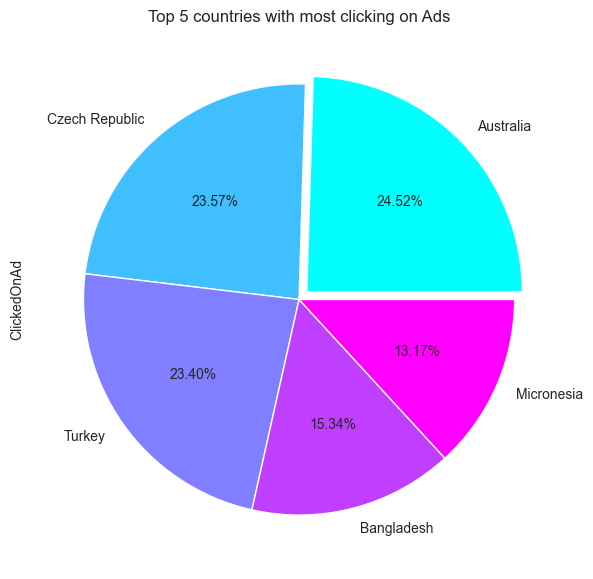

In [39]:
explode = (0.05, 0, 0, 0, 0)
data.groupby(['Country'])['ClickedOnAd'].sum().sort_values(ascending=False).iloc[:5].plot(kind='pie', y='ClickedOnAd', figsize=(15, 7), colormap='cool', autopct='%.2f%%', explode=explode)
plt.title('Top 5 countries with most clicking on Ads')
plt.gcf().set_facecolor('white')
plt.show()

By this plot we can see that these five countries have the most click on ADs than other countries and people from these countries have more chance to click on Ads rather than other countries.

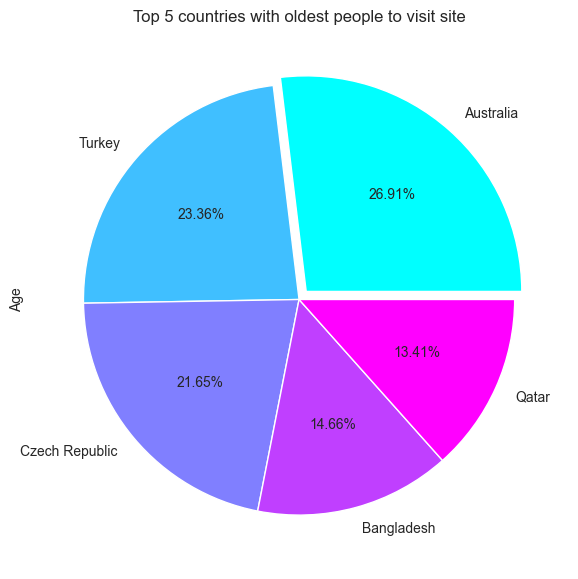

In [40]:
explode = (0.05, 0, 0, 0, 0)
data.groupby(['Country'])['Age'].sum().sort_values(ascending=False).iloc[:5].plot(kind='pie', y='ClickedOnAd', figsize=(15, 7), colormap='cool', autopct='%.2f%%', explode=explode)
plt.title('Top 5 countries with oldest people to visit site')
plt.gcf().set_facecolor('white')
plt.show()

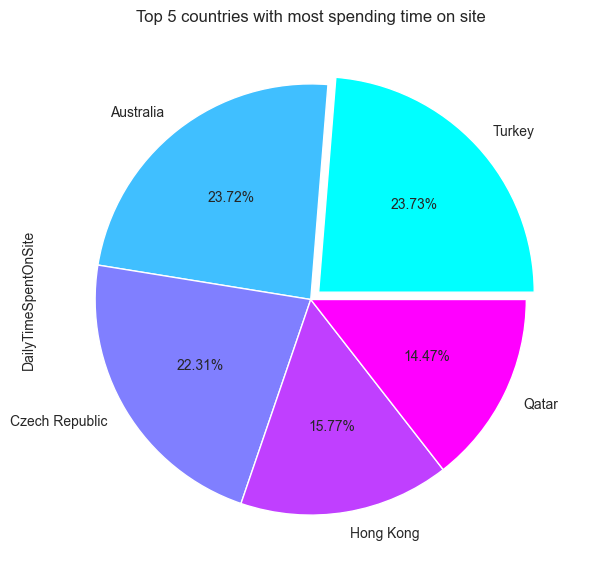

In [41]:
explode = (0.05, 0, 0, 0, 0)
data.groupby(['Country'])['DailyTimeSpentOnSite'].sum().sort_values(ascending=False).iloc[:5].plot(kind='pie', y='ClickedOnAd', figsize=(15, 7), colormap='cool', autopct='%.2f%%', explode=explode)
plt.title('Top 5 countries with most spending time on site')
plt.gcf().set_facecolor('white')
plt.show()

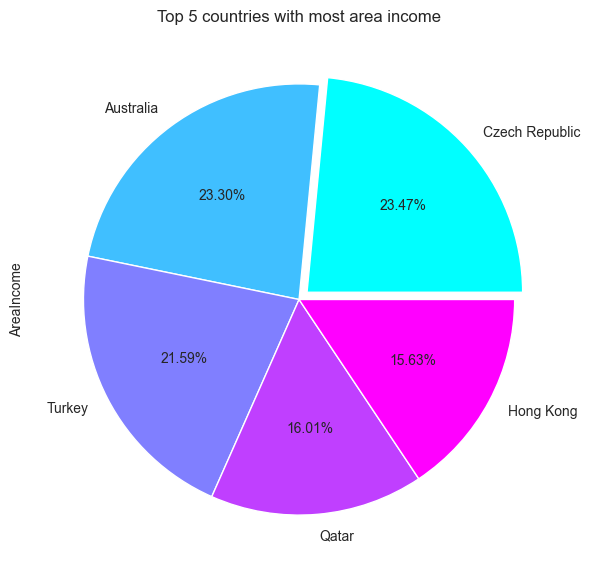

In [42]:
explode = (0.05, 0, 0, 0, 0)
data.groupby(['Country'])['AreaIncome'].sum().sort_values(ascending=False).iloc[:5].plot(kind='pie', y='ClickedOnAd', figsize=(15, 7), colormap='cool', autopct='%.2f%%', explode=explode)
plt.title('Top 5 countries with most area income')
plt.gcf().set_facecolor('white')
plt.show()

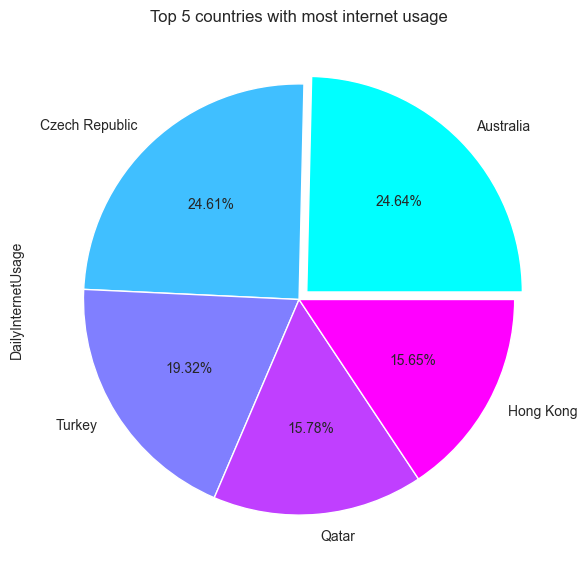

In [43]:
explode = (0.05, 0, 0, 0, 0)
data.groupby(['Country'])['DailyInternetUsage'].sum().sort_values(ascending=False).iloc[:5].plot(kind='pie', y='ClickedOnAd', figsize=(15, 7), colormap='cool', autopct='%.2f%%', explode=explode)
plt.title('Top 5 countries with most internet usage')
plt.gcf().set_facecolor('white')
plt.show()

The team has created bar plots to visualize the top five countries with the highest values for four different features: average age, daily internet usage, area income, and daily time spent on the site. The goal of this visualization was to validate the findings from the previous analysis, which had compared two groups on these same features.

However, upon closer inspection, I have noticed that the countries with the highest values in these bar plots do not match the countries that were analyzed in the previous study. This means that the data being displayed in the bar plots is not directly relevant to the groups that were the focus of the previous analysis.

Let's change the column of timestamp to format ["Morning", "Noon", "Afternoon", "Evening", "Night"] and then encode that.

In [44]:
data['Timestamp'] = pd.to_datetime(data['Timestamp'])

# Define the hour ranges for each part of the day
parts_of_day = {
    'Morning': (6, 12),
    'Noon': (12, 14),
    'Afternoon': (14, 18),
    'Evening': (18, 21),
    'Night': [(0, 6), (21, 24)]
}

# Create a new column with the part of the day
data['PartOfDay'] = data['Timestamp'].dt.hour.apply(lambda hour: next((part for part, hours in parts_of_day.items() if isinstance(hours, tuple) and hours[0] <= hour < hours[1] or isinstance(hours, list) and any(h[0] <= hour < h[1] for h in hours)), 'Unknown'))
data

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3864\132215589.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Timestamp'] = pd.to_datetime(data['Timestamp'])
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3864\132215589.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['PartOfDay'] = data['Timestamp'].dt.hour.apply(lambda hour: next((part for part, hours in parts_of_day.items() if isinstance(hours, tuple) and hours[0] <= hour < hours[1] or isinstance(hours, list) and any(h[0] <= hour < h[1] fo

,DailyTimeSpentOnSite,Age,AreaIncome,DailyInternetUsage,AdTopicLine,City,Gender,Country,Timestamp,ClickedOnAd,group,PartOfDay
0,62.26,32.0,69481.85,172.83,Decentralized real-time circuit,Lisafort,Male,Svalbard & Jan Mayen Islands,2016-06-09 21:43:05,0,0,Night
1,41.73,31.0,61840.26,207.17,Optional full-range projection,West Angelabury,Male,Singapore,2016-01-16 17:56:05,0,1,Afternoon
2,44.40,30.0,57877.15,172.83,Total 5thgeneration standardization,Reyesfurt,Female,Guadeloupe,2016-06-29 10:50:45,0,2,Morning
3,59.88,28.0,56180.93,207.17,Balanced empowering success,New Michael,Female,Zambia,2016-06-21 14:32:32,0,3,Afternoon
4,49.21,30.0,54324.73,201.58,Total 5thgeneration standardization,West Richard,Female,Qatar,2016-07-21 10:54:35,1,2,Morning
...,...,...,...,...,...,...,...,...,...,...,...,...
9994,41.73,28.0,39799.73,217.37,Realigned intangible benchmark,Dustinchester,Female,Zambia,2016-03-20 02:44:13,0,184,Night
9995,41.73,31.0,61840.26,207.17,Profound executive flexibility,West Angelabury,Male,Singapore,2016-01-03 03:22:15,1,256,Night
9996,41.73,28.0,51501.38,120.49,Managed zero tolerance concept,Kennedyfurt,Male,Luxembourg,2016-05-28 12:20:15,0,61,Noon
9997,55.60,39.0,38067.08,124.44,Intuitive exuding service-desk,North Randy,Female,Egypt,2016-01-05 11:53:17,0,15,Morning


In [45]:
data['Timestamp'] = pd.to_datetime(data['Timestamp'])
data['Timestamp'] = data['Timestamp'].dt.time
data

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3864\1536187771.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Timestamp'] = pd.to_datetime(data['Timestamp'])
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3864\1536187771.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Timestamp'] = data['Timestamp'].dt.time


,DailyTimeSpentOnSite,Age,AreaIncome,DailyInternetUsage,AdTopicLine,City,Gender,Country,Timestamp,ClickedOnAd,group,PartOfDay
0,62.26,32.0,69481.85,172.83,Decentralized real-time circuit,Lisafort,Male,Svalbard & Jan Mayen Islands,21:43:05,0,0,Night
1,41.73,31.0,61840.26,207.17,Optional full-range projection,West Angelabury,Male,Singapore,17:56:05,0,1,Afternoon
2,44.40,30.0,57877.15,172.83,Total 5thgeneration standardization,Reyesfurt,Female,Guadeloupe,10:50:45,0,2,Morning
3,59.88,28.0,56180.93,207.17,Balanced empowering success,New Michael,Female,Zambia,14:32:32,0,3,Afternoon
4,49.21,30.0,54324.73,201.58,Total 5thgeneration standardization,West Richard,Female,Qatar,10:54:35,1,2,Morning
...,...,...,...,...,...,...,...,...,...,...,...,...
9994,41.73,28.0,39799.73,217.37,Realigned intangible benchmark,Dustinchester,Female,Zambia,02:44:13,0,184,Night
9995,41.73,31.0,61840.26,207.17,Profound executive flexibility,West Angelabury,Male,Singapore,03:22:15,1,256,Night
9996,41.73,28.0,51501.38,120.49,Managed zero tolerance concept,Kennedyfurt,Male,Luxembourg,12:20:15,0,61,Noon
9997,55.60,39.0,38067.08,124.44,Intuitive exuding service-desk,North Randy,Female,Egypt,11:53:17,0,15,Morning


<AxesSubplot: >

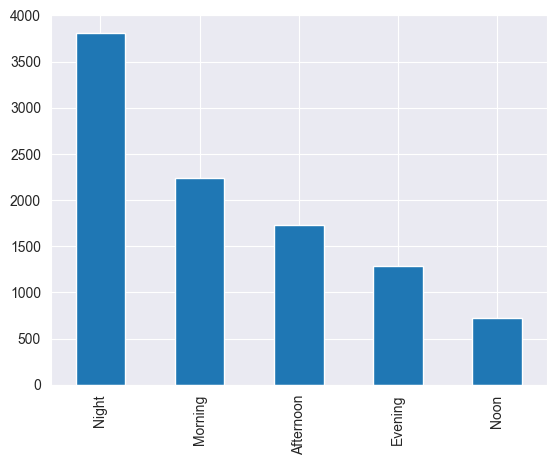

In [46]:
plot_df = data.PartOfDay.value_counts()
plot_df.plot(kind="bar")

As we can see people visited site on night more often.

Text(0.5, 1.0, 'Proportions of Part of day by Clicking Groups')

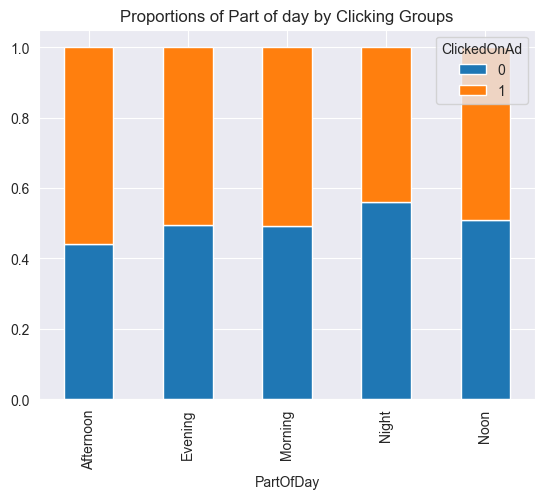

In [47]:
data.groupby('PartOfDay')['ClickedOnAd'].value_counts(normalize=True).unstack().plot(kind='bar', stacked=True)
plt.title('Proportions of Part of day by Clicking Groups')

Also there is a higher chance to click on the ADs in nights.